# DSAC B747 step-response: быстрая проверка лучшего чекпоинта

Небольшой ноутбук, который находит лучший чекпоинт из `runs/…/best_eval/metrics.json`, грузит DSAC и строит переходный процесс по референсу 5° @ 5 c. Если нужен другой путь к метрикам, укажите его в конфигурации ниже.


In [ ]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch

from tensoraerospace.agent import DSAC
from tensoraerospace.envs.b747 import ImprovedB747Env



2026-01-04 19:16:55.070204: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-04 19:16:55.070235: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-04 19:16:55.071066: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-04 19:16:55.076216: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-04 19:16:55.825059: W tensorflow/compiler/tf2

In [ ]:
# --- Конфигурация путей ---
PROJECT_ROOT = Path.cwd().resolve()
RUNS_ROOT = PROJECT_ROOT / "runs"
# Укажите metrics.json вручную, если нужен конкретный запуск
METRICS_PATH = None  # например: PROJECT_ROOT / "runs/dsac_b747_step_response_20250101_120000/best_eval/metrics.json"


def find_latest_metrics(runs_root: Path) -> Path:
    candidates = sorted(runs_root.glob("dsac_b747_step_response_*/best_eval/metrics.json"))
    if not candidates:
        raise FileNotFoundError("Не найден metrics.json. Задайте METRICS_PATH вручную.")
    # Берём самый свежий по времени модификации
    return max(candidates, key=lambda p: p.stat().st_mtime)


metrics_path = Path(METRICS_PATH) if METRICS_PATH else find_latest_metrics(RUNS_ROOT)
metrics_path = metrics_path.resolve()
print(f"Используем metrics.json: {metrics_path}")



Используем metrics.json: /home/mr8bit/Projects/TensorAeroSpace/example/reinforcement_learning/runs/dsac_b747_step_response_20260104_100817/best_eval/metrics.json


In [ ]:
# --- Читаем metrics.json и находим путь к чекпоинту ---
with open(metrics_path, "r", encoding="utf-8") as f:
    eval_metrics = json.load(f)

ckpt_dir = Path(eval_metrics["checkpoint_dir"]).resolve()
print("Лучший eval: ")
print(json.dumps(eval_metrics, indent=2))
print(f"\nЧекпоинт: {ckpt_dir}")



Лучший eval: 
{
  "return_sum": -8.198605636018533,
  "return_mean": -0.04119902329657554,
  "steps": 199,
  "settled": false,
  "settle_time_s": -1.0,
  "overshoot_ratio": 0.0,
  "sign_changes": 0,
  "checkpoint_dir": "/home/mr8bit/Projects/TensorAeroSpace/example/reinforcement_learning/runs/dsac_b747_step_response_20260104_100817/best_eval/Jan04_12-14-43_DSAC"
}

Чекпоинт: /home/mr8bit/Projects/TensorAeroSpace/example/reinforcement_learning/runs/dsac_b747_step_response_20260104_100817/best_eval/Jan04_12-14-43_DSAC


In [ ]:
def pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


device = pick_device()
print(f"Device: {device}")



Device: cuda


In [ ]:
def load_dsac_checkpoint(folder: Path, env: ImprovedB747Env, *, device: str = "cpu") -> Tuple[DSAC, Dict[str, Any]]:
    folder = Path(folder)
    config_path = folder / "config.json"
    if not config_path.exists():
        raise FileNotFoundError(f"Не найден config.json в {folder}")

    with open(config_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    params = dict(cfg["policy"]["params"])
    params["device"] = device

    agent = DSAC(env=env, **params)

    # Грузим веса
    agent.critic = torch.load(folder / "critic.pth", map_location=device, weights_only=False)
    agent.policy = torch.load(folder / "policy.pth", map_location=device, weights_only=False)
    agent.critic_target = torch.load(folder / "critic_target.pth", map_location=device, weights_only=False)

    agent.critic = agent.critic.to(device)
    agent.policy = agent.policy.to(device)
    agent.critic_target = agent.critic_target.to(device)

    # Восстанавливаем alpha, если есть
    log_alpha_path = folder / "log_alpha.pth"
    if getattr(agent, "automatic_entropy_tuning", False) and log_alpha_path.exists():
        loaded_alpha = torch.load(log_alpha_path, map_location=device, weights_only=False)
        if isinstance(loaded_alpha, dict) and "log_alpha" in loaded_alpha:
            agent.log_alpha.data.copy_(loaded_alpha["log_alpha"].to(agent.device))
            agent.alpha = float(agent.log_alpha.exp().item())

    agent.policy.eval()
    agent.critic.eval()
    agent.critic_target.eval()
    return agent, cfg


def make_reference(*, dt: float, tn: float, step_deg: float, step_time_sec: float) -> np.ndarray:
    num_steps = int(tn / dt) + 1
    ref = np.zeros((1, num_steps), dtype=np.float32)
    step_idx = int(np.clip(round(step_time_sec / dt), 0, num_steps - 1))
    ref[:, step_idx:] = np.deg2rad(step_deg)
    return ref


def make_eval_env(dt: float = 0.1, tn: float = 20.0, step_deg: float = 1.0, step_time_sec: float = 5.0) -> ImprovedB747Env:
    return ImprovedB747Env(
        initial_state=np.array([0.0, 0.0, 0.0, 0.0], dtype=float),
        reference_signal=make_reference(dt=dt, tn=tn, step_deg=step_deg, step_time_sec=step_time_sec),
        number_time_steps=int(tn / dt) + 1,
        dt=dt,
        reward_mode="step_response",
    )


def eval_episode(agent: DSAC, env: ImprovedB747Env) -> Tuple[Dict[str, Any], Dict[str, np.ndarray]]:
    obs, _ = env.reset()
    rewards = []
    terminated = False
    truncated = False
    traj = {"t": [], "theta_deg": [], "target_deg": [], "err_deg": [], "u_norm": []}

    while not (terminated or truncated):
        action = agent.select_action(obs, evaluate=True)
        obs, r, terminated, truncated, info = env.step(action)
        rewards.append(float(r))
        t = len(traj["t"]) * float(env.dt)
        traj["t"].append(t)
        traj["theta_deg"].append(np.rad2deg(info["theta_rad"]))
        traj["target_deg"].append(np.rad2deg(info["target_theta_rad"]))
        traj["err_deg"].append(np.rad2deg(info["err_theta_rad"]))
        traj["u_norm"].append(float(info["u_norm"]))

    traj = {k: np.asarray(v, dtype=np.float32) for k, v in traj.items()}
    metrics = {
        "return_sum": float(np.sum(rewards)),
        "return_mean": float(np.mean(rewards)) if rewards else 0.0,
        "steps": int(len(rewards)),
        "settled": bool(info.get("settled", False)),
        "settle_time_s": float(info.get("settle_time_s", -1.0)),
        "overshoot_ratio": float(info.get("overshoot_ratio", 0.0)),
        "sign_changes": int(info.get("sign_changes", 0)),
    }
    return metrics, traj



In [ ]:
# --- Создаём env, грузим агент, оцениваем ---
env_eval = make_eval_env()
agent, cfg = load_dsac_checkpoint(ckpt_dir, env_eval, device=device)

run_metrics, traj = eval_episode(agent, env_eval)
print("Метрики эпизода:")
print(json.dumps(run_metrics, indent=2))



Метрики эпизода:
{
  "return_sum": -7.779260275533268,
  "return_mean": -0.039091760178559136,
  "steps": 199,
  "settled": false,
  "settle_time_s": -1.0,
  "overshoot_ratio": 0.0,
  "sign_changes": 0
}


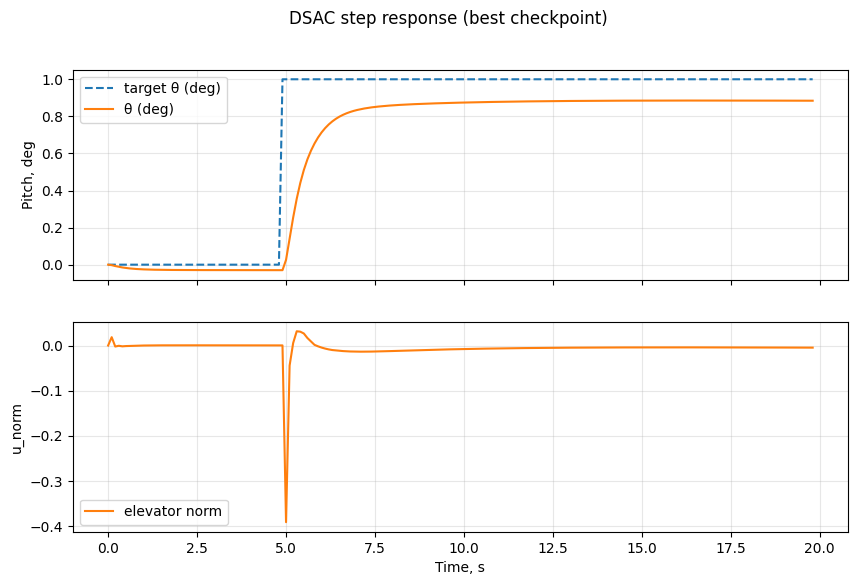

In [ ]:
# --- График переходного процесса ---
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(traj["t"], traj["target_deg"], "--", label="target θ (deg)")
ax[0].plot(traj["t"], traj["theta_deg"], label="θ (deg)")
ax[0].set_ylabel("Pitch, deg")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(traj["t"], traj["u_norm"], color="tab:orange", label="elevator norm")
ax[1].set_ylabel("u_norm")
ax[1].set_xlabel("Time, s")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

fig.suptitle("DSAC step response (best checkpoint)")
plt.show()



**Подсказки**
- Если запусков несколько, `METRICS_PATH = ...` укажет конкретный `metrics.json`.
- Для другого теста поменяйте `step_deg` / `step_time_sec` в `make_eval_env`.
- Можно повторять `eval_episode` несколько раз, если динамика стохастическая.
